# **1. Perkenalan Dataset**


## Dataset: Wine Quality (Red Wine)

Dataset yang digunakan adalah **Red Wine Quality** dari UCI Machine Learning Repository.

**Sumber:** https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

**Deskripsi:**
Dataset ini berisi informasi tentang varian wine merah Portugal "Vinho Verde". Dataset memiliki 1.599 sampel dengan 11 fitur fisikokimia sebagai input dan 1 variabel output (kualitas wine).

**Fitur Input:**
1. `fixed acidity` - keasaman tetap
2. `volatile acidity` - keasaman volatil
3. `citric acid` - asam sitrat
4. `residual sugar` - gula residu
5. `chlorides` - klorida
6. `free sulfur dioxide` - sulfur dioksida bebas
7. `total sulfur dioxide` - total sulfur dioksida
8. `density` - densitas
9. `pH` - pH
10. `sulphates` - sulfat
11. `alcohol` - kadar alkohol

**Target:**
- `quality` → dikonversi menjadi binary: **1 (good)** jika quality >= 7, **0 (bad)** jika quality < 7

**Task:** Binary Classification


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('Library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Library berhasil diimport!
Pandas version: 2.2.3
NumPy version: 1.26.4


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
# Memuat dataset dari URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# Simpan raw data
df.to_csv('winequality_raw.csv', index=False)

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'\nLima baris pertama:')
df.head()

Dataset berhasil dimuat!
Shape: (1599, 12)

Lima baris pertama:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Informasi dasar dataset
print('Informasi Dataset:')
print('='*50)
df.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Statistik deskriptif
print('Statistik Deskriptif:')
df.describe()

Statistik Deskriptif:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
#Type your code here
# 4.1 Cek Missing Values
print('Missing Values per Kolom:')
print('='*40)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing Values per Kolom:
                      Missing Count  Missing %
fixed acidity                     0        0.0
volatile acidity                  0        0.0
citric acid                       0        0.0
residual sugar                    0        0.0
chlorides                         0        0.0
free sulfur dioxide               0        0.0
total sulfur dioxide              0        0.0
density                           0        0.0
pH                                0        0.0
sulphates                         0        0.0
alcohol                           0        0.0
quality                           0        0.0

Total missing values: 0


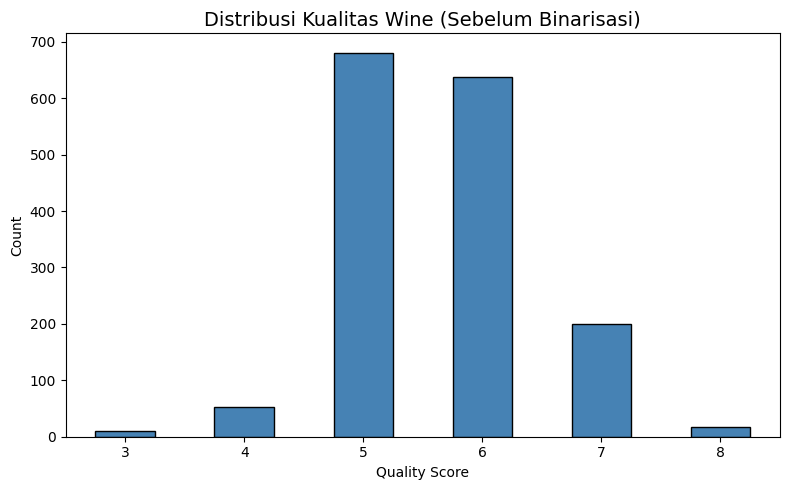

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [6]:
# 4.2 Distribusi variabel target (quality)
plt.figure(figsize=(8, 5))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kualitas Wine (Sebelum Binarisasi)', fontsize=14)
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['quality'].value_counts())

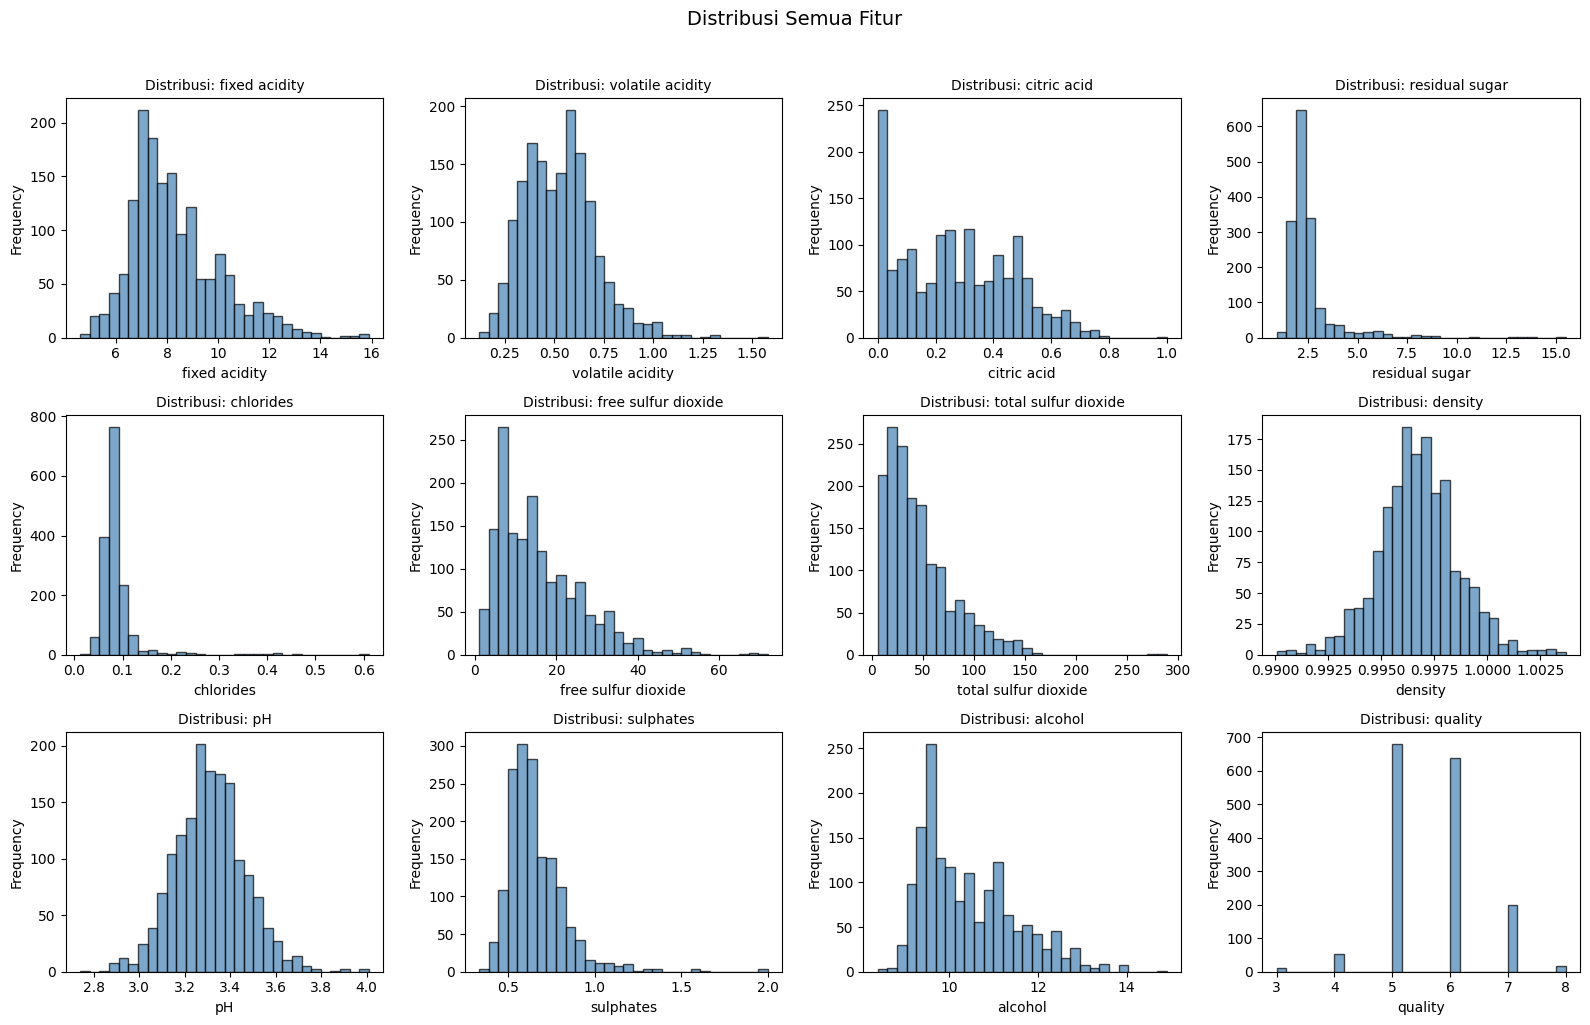

In [7]:
# 4.3 Distribusi semua fitur numerik
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi: {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hapus subplot kosong
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Semua Fitur', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

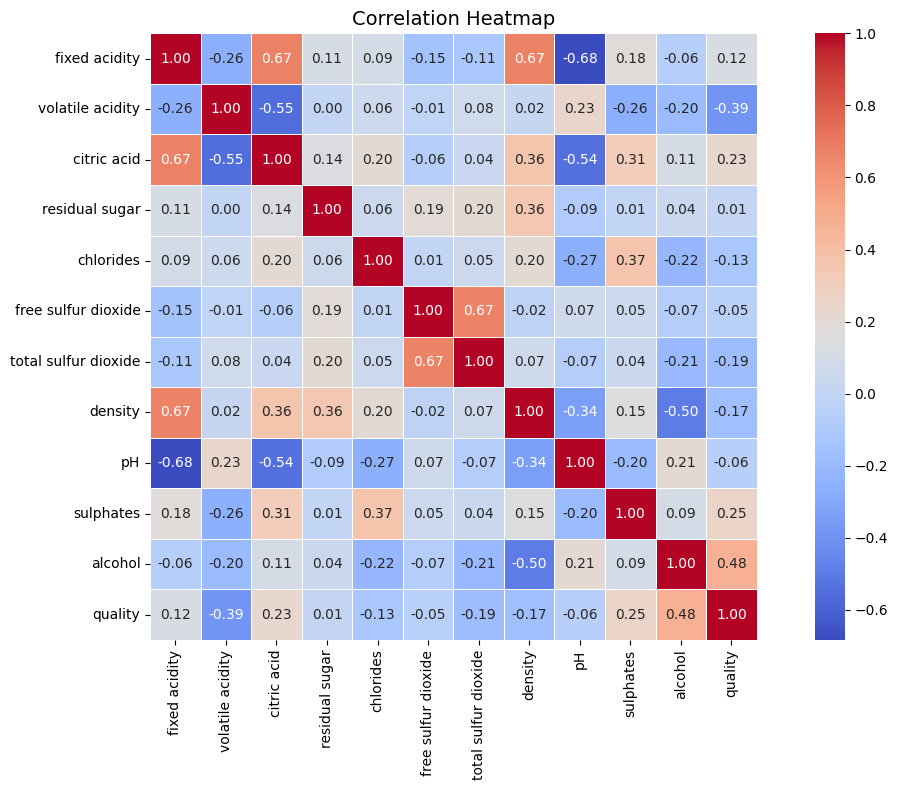

In [8]:
# 4.4 Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

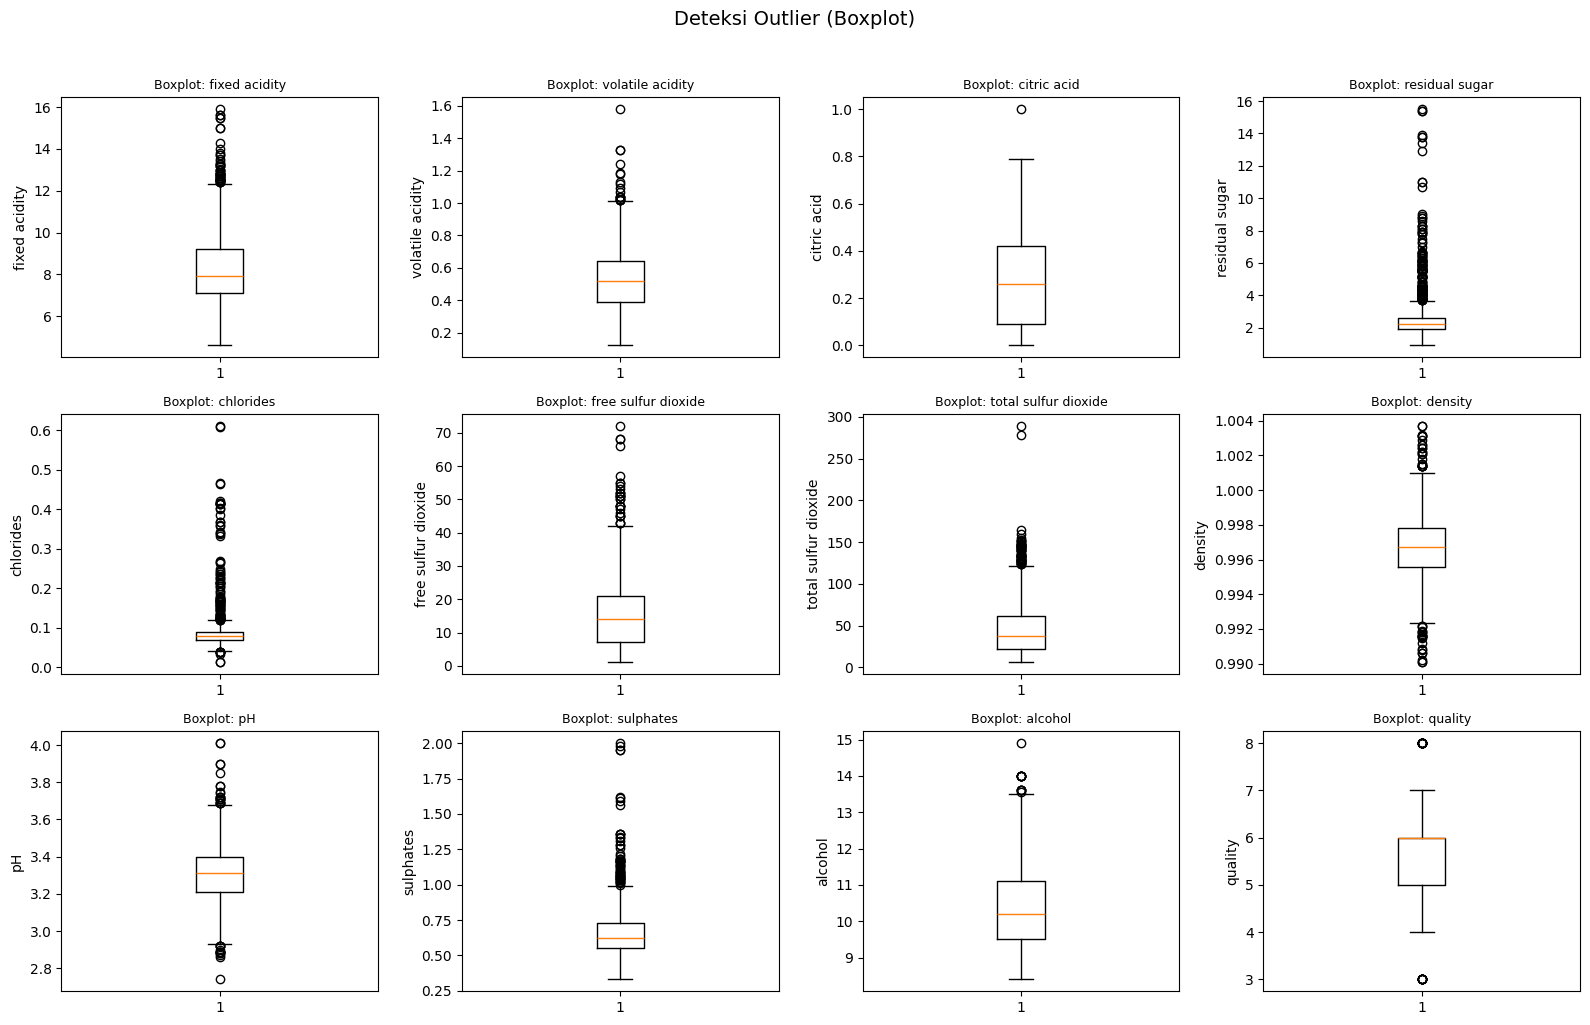

In [9]:
# 4.5 Deteksi Outlier dengan Boxplot
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}', fontsize=9)
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Deteksi Outlier (Boxplot)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# 4.6 Cek Duplikasi
print(f'Jumlah data duplikat: {df.duplicated().sum()}')
print(f'Persentase duplikat: {df.duplicated().sum()/len(df)*100:.2f}%')

Jumlah data duplikat: 240
Persentase duplikat: 15.01%


Korelasi fitur terhadap quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


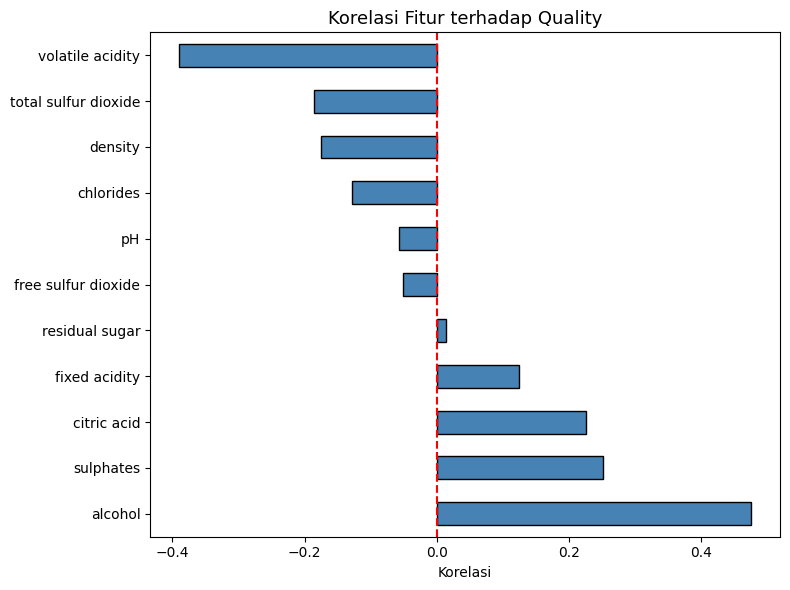

In [11]:
# 4.7 Analisis korelasi fitur terhadap quality
correlations = df.corr()['quality'].sort_values(ascending=False)
print('Korelasi fitur terhadap quality:')
print(correlations)

plt.figure(figsize=(8, 6))
correlations.drop('quality').plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Korelasi Fitur terhadap Quality', fontsize=13)
plt.xlabel('Korelasi')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# 5.1 Binarisasi Target
# quality >= 7 -> 1 (good), quality < 7 -> 0 (bad)
df['quality_label'] = (df['quality'] >= 7).astype(int)
print('Distribusi label baru:')
print(df['quality_label'].value_counts())
print(f'\nPersentase kelas positif (good): {df["quality_label"].mean()*100:.2f}%')

Distribusi label baru:
quality_label
0    1382
1     217
Name: count, dtype: int64

Persentase kelas positif (good): 13.57%


In [13]:
# 5.2 Hapus kolom quality asli
df = df.drop(columns=['quality'])
print('Kolom setelah drop quality:')
print(df.columns.tolist())

Kolom setelah drop quality:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality_label']


In [14]:
# 5.3 Hapus Data Duplikat
print(f'Jumlah data sebelum hapus duplikat: {len(df)}')
df = df.drop_duplicates()
print(f'Jumlah data setelah hapus duplikat: {len(df)}')
df = df.reset_index(drop=True)

Jumlah data sebelum hapus duplikat: 1599
Jumlah data setelah hapus duplikat: 1359


In [15]:
# 5.4 Penanganan Missing Values (jika ada)
print(f'Missing values sebelum handling: {df.isnull().sum().sum()}')
# Isi missing values numerik dengan median (robust terhadap outlier)
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Kolom {col}: filled with median = {median_val:.4f}')
print(f'Missing values setelah handling: {df.isnull().sum().sum()}')

Missing values sebelum handling: 0
Missing values setelah handling: 0


In [16]:
# 5.5 Deteksi dan Penanganan Outlier menggunakan IQR
feature_cols = [c for c in df.columns if c != 'quality_label']

print('Penanganan Outlier dengan IQR Capping:')
print('='*50)

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    if outlier_count > 0:
        print(f'{col}: {outlier_count} outlier -> capped ke [{lower:.4f}, {upper:.4f}]')

    # Capping (winsorizing)
    df[col] = df[col].clip(lower=lower, upper=upper)

print('\nOutlier handling selesai!')

Penanganan Outlier dengan IQR Capping:
fixed acidity: 41 outlier -> capped ke [3.9500, 12.3500]
volatile acidity: 19 outlier -> capped ke [0.0150, 1.0150]
citric acid: 1 outlier -> capped ke [-0.4200, 0.9400]
residual sugar: 126 outlier -> capped ke [0.8500, 3.6500]
chlorides: 87 outlier -> capped ke [0.0385, 0.1225]
free sulfur dioxide: 26 outlier -> capped ke [-14.0000, 42.0000]
total sulfur dioxide: 45 outlier -> capped ke [-39.5000, 124.5000]
density: 35 outlier -> capped ke [0.9923, 1.0011]
pH: 28 outlier -> capped ke [2.9250, 3.6850]
sulphates: 55 outlier -> capped ke [0.2800, 1.0000]
alcohol: 12 outlier -> capped ke [7.1000, 13.5000]

Outlier handling selesai!


In [17]:
# 5.6 Pisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['quality_label'])
y = df['quality_label']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Distribusi y:')
print(y.value_counts())

Shape X: (1359, 11)
Shape y: (1359,)
Distribusi y:
quality_label
0    1175
1     184
Name: count, dtype: int64


In [18]:
# 5.7 Normalisasi / Standarisasi Fitur menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Statistik setelah standarisasi:')
print(X_scaled.describe().round(4))

Statistik setelah standarisasi:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count      1359.0000         1359.0000    1359.0000       1359.0000   
mean         -0.0000           -0.0000       0.0000         -0.0000   
std           1.0004            1.0004       1.0004          1.0004   
min          -2.2224           -2.3016      -1.3942         -2.3448   
25%          -0.7143           -0.7779      -0.9333         -0.6983   
50%          -0.2317           -0.0442      -0.0629         -0.2043   
75%           0.5525            0.6330       0.8075          0.4543   
max           2.4527            2.7493       3.4188          2.1832   

       chlorides  free sulfur dioxide  total sulfur dioxide    density  \
count  1359.0000            1359.0000             1359.0000  1359.0000   
mean      0.0000              -0.0000                0.0000    -0.0000   
std       1.0004               1.0004                1.0004     1.0004   
min      -2.3174              -1

In [19]:
# 5.8 Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train distribusi:\n{y_train.value_counts()}')
print(f'y_test distribusi:\n{y_test.value_counts()}')

X_train shape: (1087, 11)
X_test shape:  (272, 11)
y_train distribusi:
quality_label
0    940
1    147
Name: count, dtype: int64
y_test distribusi:
quality_label
0    235
1     37
Name: count, dtype: int64


In [20]:
# 5.9 Simpan data hasil preprocessing
import os
os.makedirs('winequality_preprocessing', exist_ok=True)

# Gabungkan kembali untuk disimpan
train_data = X_train.copy()
train_data['quality_label'] = y_train.values
test_data = X_test.copy()
test_data['quality_label'] = y_test.values

train_data.to_csv('winequality_preprocessing/train.csv', index=False)
test_data.to_csv('winequality_preprocessing/test.csv', index=False)

# Simpan juga full preprocessed dataset
full_preprocessed = X_scaled.copy()
full_preprocessed['quality_label'] = y.values
full_preprocessed.to_csv('winequality_preprocessing/winequality_preprocessed.csv', index=False)

print('Dataset preprocessing berhasil disimpan!')
print('File tersimpan di folder winequality_preprocessing/')
print(f'  - train.csv: {train_data.shape}')
print(f'  - test.csv:  {test_data.shape}')
print(f'  - winequality_preprocessed.csv: {full_preprocessed.shape}')

Dataset preprocessing berhasil disimpan!
File tersimpan di folder winequality_preprocessing/
  - train.csv: (1087, 12)
  - test.csv:  (272, 12)
  - winequality_preprocessed.csv: (1359, 12)


In [21]:
# 5.10 Verifikasi akhir
print('=== RINGKASAN PREPROCESSING ===')
print(f'Dataset asli: 1599 baris, 12 kolom')
print(f'Setelah hapus duplikat: {len(df)} baris')
print(f'Fitur input: {X.shape[1]} fitur')
print(f'Teknik yang diterapkan:')
print(f'  ✓ Binarisasi target (quality >= 7 = good)')
print(f'  ✓ Penghapusan data duplikat')
print(f'  ✓ Penanganan missing values (median imputation)')
print(f'  ✓ Penanganan outlier (IQR capping)')
print(f'  ✓ Standarisasi fitur (StandardScaler)')
print(f'  ✓ Train-test split 80:20 (stratified)')
print(f'\nData siap untuk pelatihan model!')

=== RINGKASAN PREPROCESSING ===
Dataset asli: 1599 baris, 12 kolom
Setelah hapus duplikat: 1359 baris
Fitur input: 11 fitur
Teknik yang diterapkan:
  ✓ Binarisasi target (quality >= 7 = good)
  ✓ Penghapusan data duplikat
  ✓ Penanganan missing values (median imputation)
  ✓ Penanganan outlier (IQR capping)
  ✓ Standarisasi fitur (StandardScaler)
  ✓ Train-test split 80:20 (stratified)

Data siap untuk pelatihan model!
